In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv(r"C:\Users\edwin\OneDrive\Desktop\development_journey\20.Machine Learning\unsupervised\kmeans_works\wholesale_customers\Wholesale customers data.csv.xls")

In [15]:
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [16]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [17]:
df[df.duplicated()]

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen


In [18]:
X = df

In [19]:
X.drop(columns=["Channel","Region"],axis=0,inplace=True)

In [20]:
X.columns

Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'], dtype='object')

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X))

In [22]:
wcss = []
K = []
from sklearn.cluster import KMeans

In [23]:
for i in range(2,12):

    km = KMeans(n_clusters=i,random_state=4,n_init=10)

    km.fit(X)

    wcss.append(km.inertia_)

    K.append(i)

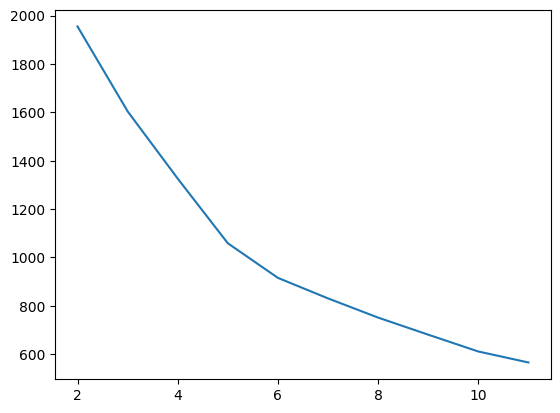

In [24]:
plt.plot(K,wcss)
plt.show()

In [25]:
km = KMeans(n_clusters=2,random_state=4,n_init=10)
km.fit(X)
Y_pred = km.predict(X)

In [26]:
X["Cluster"] = Y_pred

In [27]:
X.head()

,0,1,2,3,4,5,Cluster
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339,1
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151,1
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293,1
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411,1
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347,1


In [29]:
from sklearn.metrics import silhouette_score
print("silhouette_score: ",silhouette_score(X,Y_pred)*100)

silhouette_score:  62.18632849328799


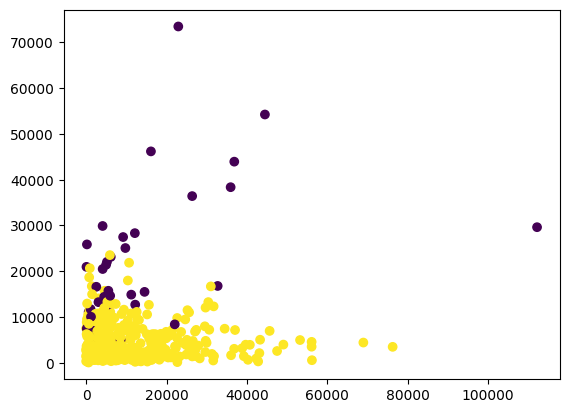

In [30]:
plt.scatter(x=df["Fresh"],y=df["Milk"],c=X["Cluster"])
# Colors each point according to its cluster label.
# This is commonly used after clustering algorithms such as K-Means Clustering.

plt.show()

In [32]:
X["Cluster"].value_counts()

Cluster
1    404
0     36
Name: count, dtype: int64

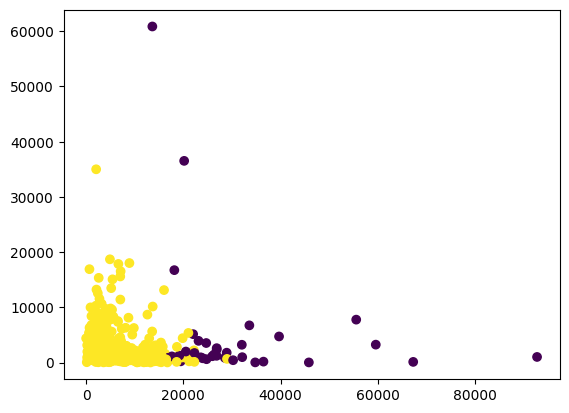

In [31]:
plt.scatter(x=df["Grocery"],y=df["Frozen"],c=X["Cluster"])
plt.show()